Data preprocessing

In [ ]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [ ]:
# Load the dataset
df = pd.read_csv('/content/soil_fertility_prediction_dataset.csv')

In [ ]:
# Checking for missing values
print(df.isnull().sum())

pH        0
EC        0
OC        0
OM        0
N         0
P         0
K         0
Zn        0
Fe        0
Cu        0
Mn        0
Sand      0
Silt      0
Clay      0
CaCO3     0
CEC       0
Output    0
dtype: int64


In [ ]:
# Encode the target variable (Output column: Fertile/Non Fertile)
label_encoder = LabelEncoder()
df['Output'] = label_encoder.fit_transform(df['Output'])  # Fertile -> 1, Non Fertile -> 0

In [ ]:
# Split features and target
X = df.drop('Output', axis=1)
y = df['Output']

In [ ]:
# Feature scaling (Standardization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled)

[[-1.04197406  0.41559319 -1.09177619 ...  0.67774568  0.66467229
   0.88022096]
 [ 1.39851414  0.0746325  -1.03282499 ... -0.4703677   0.12464205
   0.66793801]
 [-0.92757618 -0.45575078 -1.03282499 ...  0.57011005 -0.66364853
   2.42440818]
 ...
 [-0.05052573 -0.15267462  3.03480768 ... -0.07570373 -0.06987121
   0.69190544]
 [-0.31745413 -0.56940434  3.15271007 ...  0.10368899 -1.05523444
  -0.73244464]
 [-1.86182557  0.64290031  3.21166127 ...  2.04113031  0.18862667
   0.43511156]]


In [ ]:
# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
# Display the shapes of the split datasets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (80, 16)
X_test shape: (20, 16)
y_train shape: (80,)
y_test shape: (20,)


Stratified k-fold cross validation and Model Training


In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

# Initialize SVM classifier
clf = SVC(kernel='linear')

# Define Stratified KFold cross-validator with 5 splits
sk_folds = StratifiedKFold(n_splits=5)

# Perform cross-validation using StratifiedKFold
scores = cross_val_score(clf, X_train, y_train, cv=sk_folds)

# Print the cross-validation results
print("Cross Validation Scores: ", scores)
print("Average CV Score: ", scores.mean())
print("Number of CV Scores used in Average: ", len(scores))

# Train the model with the entire training set
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)

# Define evaluation function
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    print(f"Accuracy: {accuracy}")
    print(f"Precision: {precision}")
    print(f"Recall: {recall}")
    print(f"F1 Score: {f1}")
    print(f"Confusion Matrix:\n {confusion_matrix(y_test, y_pred)}\n")

Cross Validation Scores:  [0.9375 0.9375 0.875  0.875  0.9375]
Average CV Score:  0.9125
Number of CV Scores used in Average:  5


In [ ]:
print("Support Vector Machine:")
evaluate_model(clf, X_train, y_train)

Support Vector Machine:
Accuracy: 0.9875
Precision: 0.9878048780487806
Recall: 0.9875
F1 Score: 0.9874980465697766
Confusion Matrix:
 [[39  1]
 [ 0 40]]



Hyperparameter Tuning

In [ ]:
# Import necessary libraries
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVC
from sklearn.metrics import make_scorer, f1_score
import numpy as np
import pandas as pd

# Scale the data
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define a more refined parameter distribution for RandomizedSearchCV
param_dist = {
    'C': np.logspace(-2, 2, 8),
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto'],
    'degree': [2, 3, 4]
}

# Define the scorer to use, e.g., weighted F1 score if dataset is imbalanced
scorer = make_scorer(f1_score, average='weighted')

# Perform grid Search with 10-fold cross-validation
grid_search_svm = GridSearchCV(SVC(), param_dist, cv=10, scoring=scorer) # Define grid_search_svm
grid_search_svm.fit(X_train_scaled, y_train)

print(f"Best Parameters: {grid_search_svm.best_params_}")
print(f"Best Score: {grid_search_svm.best_score_}")


Best Parameters: {'C': 26.826957952797247, 'degree': 2, 'gamma': 'auto', 'kernel': 'rbf'}
Best Score: 0.9492063492063492


In [ ]:
# Get the best SVM model
best_svm = grid_search_svm.best_estimator_

# Make predictions
y_pred_svm = best_svm.predict(X_train)

# Evaluate the best model (assuming evaluate_model is a function you've defined)
evaluate_model(best_svm, X_train, y_train)

Accuracy: 0.9375
Precision: 0.9377736085053158
Recall: 0.9375
F1 Score: 0.9374902328488826
Confusion Matrix:
 [[38  2]
 [ 3 37]]



Feature importance

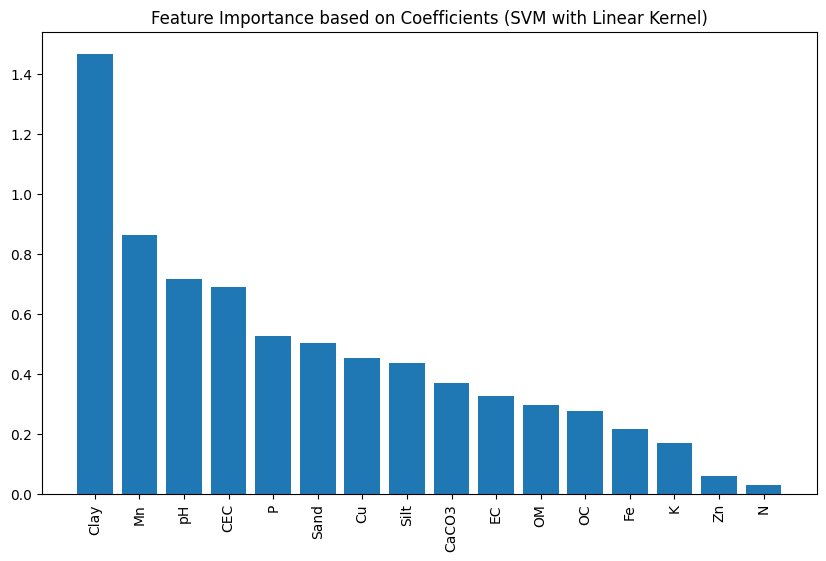

In [ ]:
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import numpy as np

# Fit the SVM model with a linear kernel
svm = SVC(kernel='linear')
svm.fit(X_train, y_train)

# Access the absolute values of the coefficients to interpret feature importance
feature_importances_svm = np.abs(svm.coef_[0])

# Sort features by importance
indices = np.argsort(feature_importances_svm)[::-1]
features = df.columns[:-1]  # Exclude the target column

# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.title("Feature Importance based on Coefficients (SVM with Linear Kernel)")
plt.bar(range(X_train.shape[1]), feature_importances_svm[indices], align="center")
plt.xticks(range(X_train.shape[1]), features[indices], rotation=90)
plt.show()


Heat map

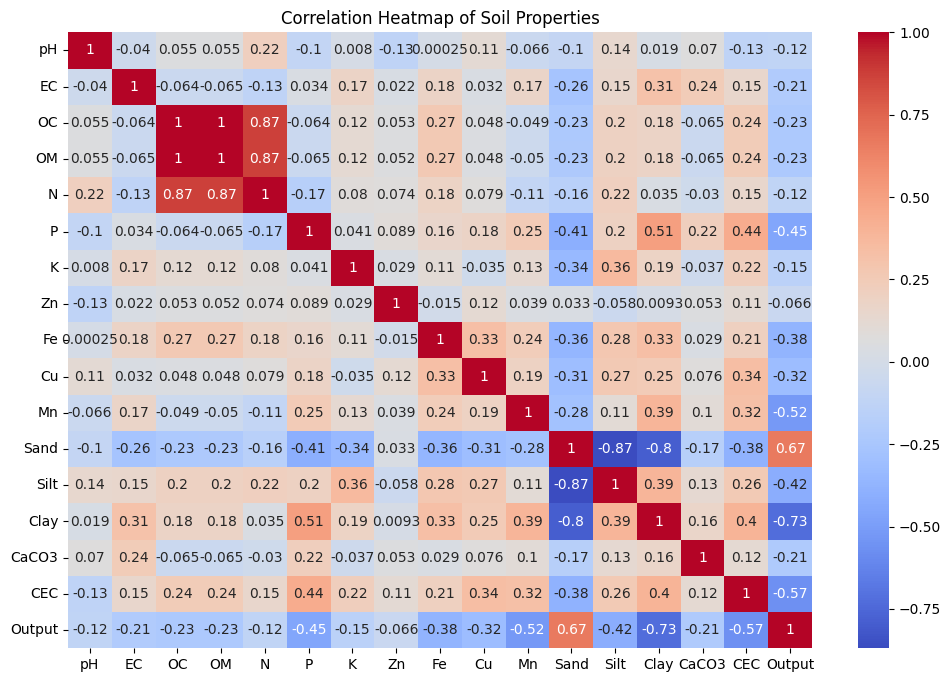

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Soil Properties")
plt.show()

Boxplotting

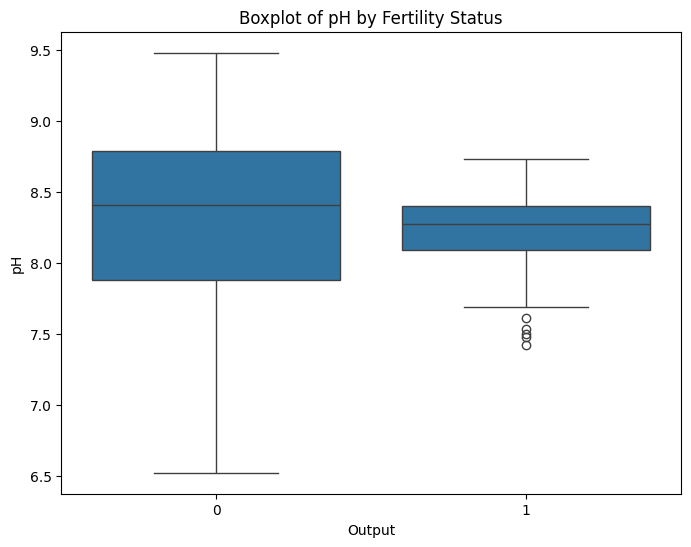

In [ ]:
# Boxplot for pH
plt.figure(figsize=(8, 6))
sns.boxplot(x='Output', y='pH', data=df)
plt.title("Boxplot of pH by Fertility Status")
plt.show()

In [ ]:
import pandas as pd

# Load your dataset
dataset_path = '/content/fertile_recommendation_dataset.csv'
df = pd.read_csv(dataset_path)

# Define a function to recommend fertilizers based on pH, N, P, and K
def recommend_fertilizer(row):
    pH = row['pH']
    N = row['N']
    P = row['P']
    K = row['K']

    recommendation = ""

    # pH based recommendation
    if pH < 5.5:
        recommendation += "Use lime to increase soil pH. "
    elif pH > 7.5:
        recommendation += "Use sulfur or acidifying fertilizers to decrease soil pH. "
    else:
        recommendation += "Soil pH is optimal. "

    # Nitrogen-based recommendation
    if N < 20:
        recommendation += "Apply 50 kg/ha of nitrogen. "
    elif N > 50:
        recommendation += "Adding a potassium-rich fertilizer will help balance nutrient levels in the soil."

    # Phosphorus-based recommendation
    if P < 10:
        recommendation += "Apply 40 kg/ha of phosphorus. "
    elif P > 50:
        recommendation += "Adding potassium without increasing phosphorus levels can help balance the soil."

    # Potassium-based recommendation
    if K < 100:
        recommendation += "Apply 50 kg/ha of potassium. "
    elif K > 200:
        recommendation += "Potassium level is high, avoid application. "

    return recommendation

# Define a function to recommend crops based on Mn, Zn, Fe, and pH values
def recommend_crops(row):
    Mn = row['Mn']
    Zn = row['Zn']
    Fe = row['Fe']
    pH = row['pH']

    # Initialize recommendation
    recommendation = ""

    # Crop recommendations based on Mn levels
    if Mn < 100:
        recommendation += "Recommended Crops (Low Mn): Wheat, Barley, Soybeans. "
    elif Mn > 200:
        recommendation += "Recommended Crops (High Mn): Potatoes, Carrots, Tomatoes. "
    else:
        recommendation += "Recommended Crops (Optimal Mn): Corn, Cotton, Rice. "

    # Crop recommendations based on Zn levels
    if Zn < 300:
        recommendation += "Recommended Crops (Low Zn): Beans, Rice, Strawberries. "
    elif Zn > 600:
        recommendation += "Recommended Crops (High Zn): Alfalfa, Clover, Broccoli. "
    else:
        recommendation += "Recommended Crops (Optimal Zn): Peas, Spinach, Cabbage. "

    # Crop recommendations based on Fe levels
    if Fe < 50:
        recommendation += "Recommended Crops (Low Fe): Lettuce, Carrots, Strawberries. "
    elif Fe > 200:
        recommendation += "Recommended Crops (High Fe): Barley, Beets, Asparagus. "
    else:
        recommendation += "Recommended Crops (Optimal Fe): Peppers, Tomatoes, Squash. "

    # Crop recommendations based on pH levels
    if pH < 5.5:
        recommendation += "Recommended Crops (Low pH): Blueberries, Potatoes, Peanuts. "
    elif pH > 7.5:
        recommendation += "Recommended Crops (High pH): Alfalfa, Asparagus, Clover. "
    else:
        recommendation += "Recommended Crops (Optimal pH): Corn, Soybeans, Wheat. "

    return recommendation

# Apply both fertilizer recommendation and crop recommendation for each row in the dataset
df['Fertilizer Recommendation'] = df.apply(recommend_fertilizer, axis=1)
df['Crop Recommendations'] = df.apply(recommend_crops, axis=1)

# Save the result to an Excel file
output_file = '/content/fertilizer_and_crop_recommendations.xlsx'
df.to_excel(output_file, index=False)

print(f"Fertilizer and crop recommendations saved to {output_file}")

Fertilizer and crop recommendations saved to /content/fertilizer_and_crop_recommendations.xlsx
